<a href="https://colab.research.google.com/github/estebanszd/Clase-Introducci-n-/blob/main/Parcial_An%C3%A1lisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importamos librerías para poder trabajar el dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
pip install gapminder

In [5]:
from gapminder import gapminder

In [6]:
gapminder.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [7]:
gapminder.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


/tmp/ipykernel_934/1199370034.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2007['log_pop'] = np.log(df_2007['pop'])


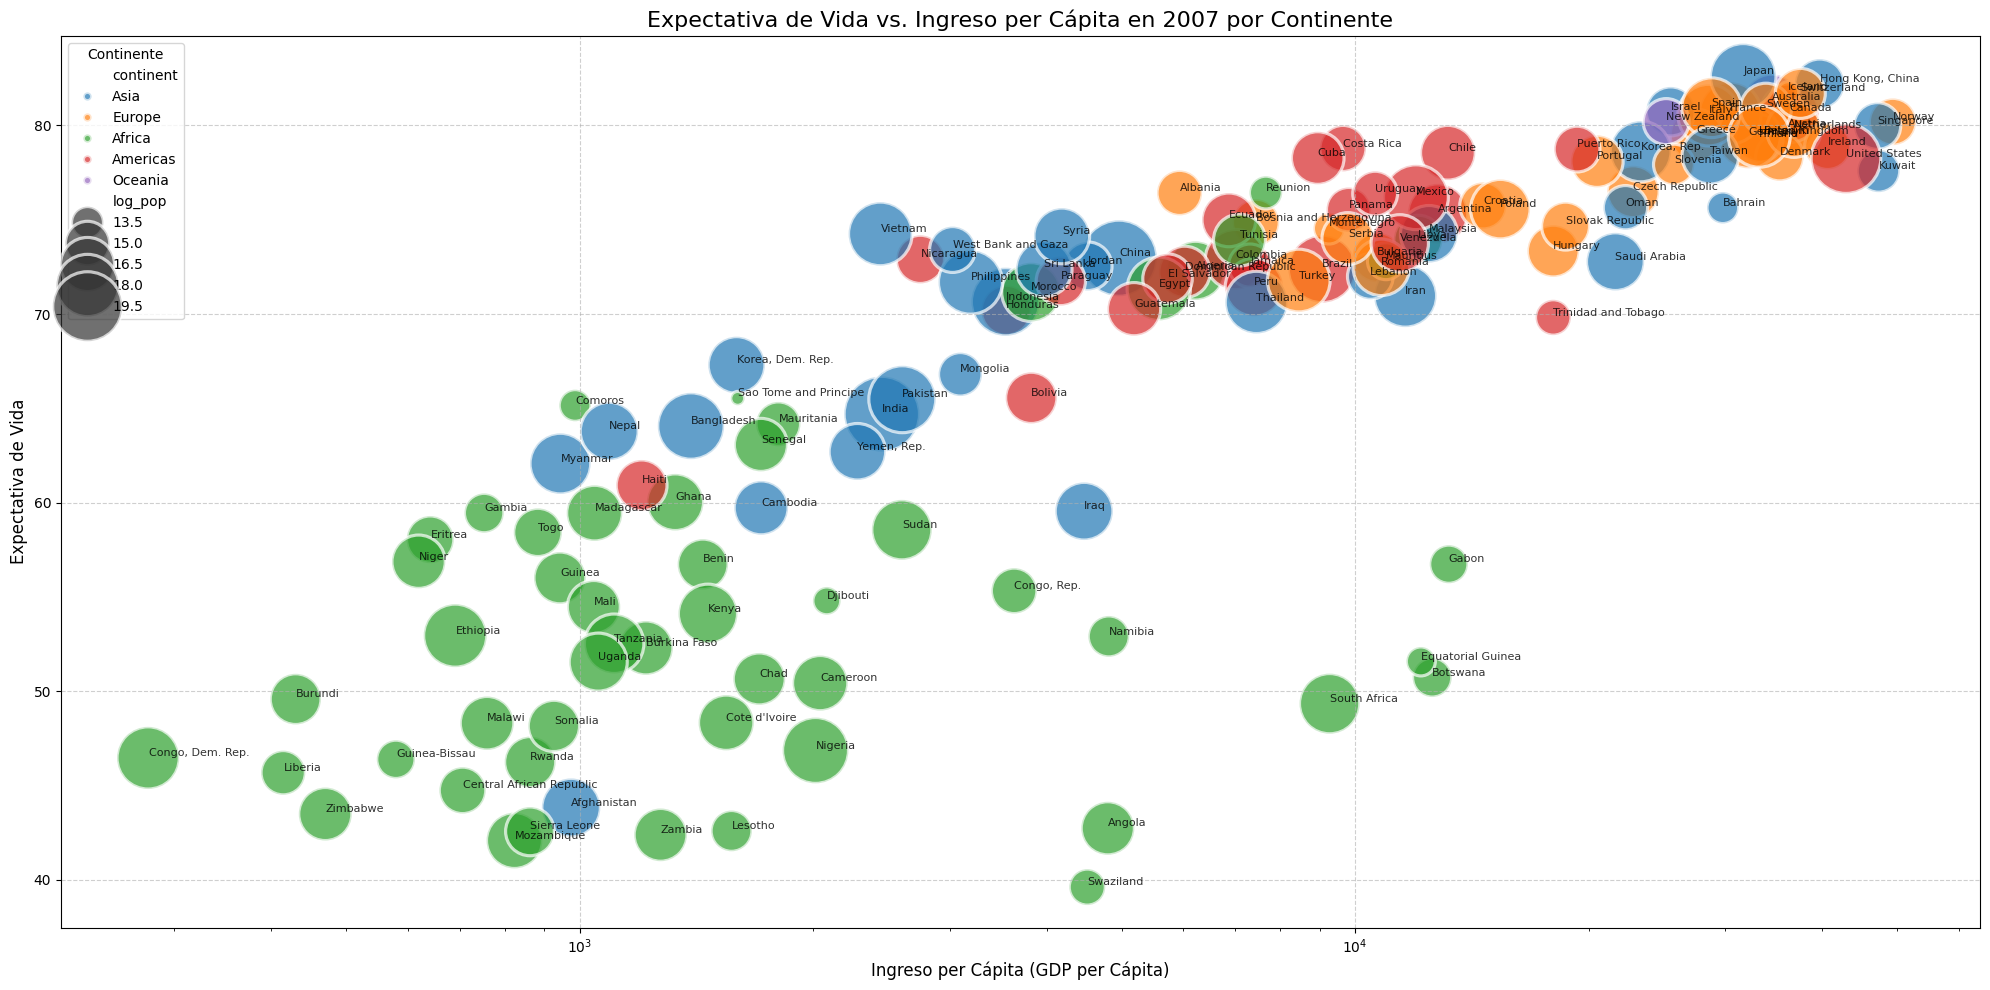

In [10]:
# Escogemos un año, en este caso 2007
df_2007 = gapminder[gapminder['year'] == 2007]
#Usamos una función logaróitmica para ajustar tamaños
df_2007['log_pop'] = np.log(df_2007['pop'])
plt.figure(figsize=(20, 10)) #Ajustamos el tamaño del grpafico
sns.scatterplot(
    data=df_2007,
    x='gdpPercap', #Es ele eje x
    y='lifeExp', #Es el eje y
    hue='continent', #Para que se puedan diferenciar por colores de continente
    size='log_pop', #Esto nos ayudará a que se distingan los tamaños de paises en base a su población
    sizes=(100, 3000),
    alpha=0.7 #Esto nos ayuda a que se puedan poner encima del otro sin taparse por completo
)

# Así se le añade el título a cada país
for i, row in df_2007.iterrows():
    plt.text(row['gdpPercap'] + 0.5, row['lifeExp'] + 0.1, row['country'], fontsize=8, alpha=0.8)

plt.title('Expectativa de Vida vs. Ingreso per Cápita en 2007 por Continente', fontsize=16)
plt.xlabel('Ingreso per Cápita (GDP per Cápita)', fontsize=12)
plt.ylabel('Expectativa de Vida', fontsize=12)
plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Continente', loc='upper left')
plt.tight_layout()
plt.show()

In [19]:
import plotly.express as px
#Este gráfico esta hecho en base a algo aprendido en clase de introducción y me parece útil de añadir ya que es interactivo
fig = px.scatter(df_2007, x='gdpPercap', y='lifeExp',
                 color='continent',
                 symbol='continent',
                 hover_data=["country", 'pop', 'lifeExp'], #Agrega esta info al popup
                 title="Expectativa de vida vs ingreso per capita por paises",
                 labels={'gdpPercap': 'Ingreso per Cápita (GDP per Cápita)', 'lifeExp': 'Expectativa de Vida'})
fig.show()